In [1]:
!nvidia-smi

Sat Mar 21 00:29:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.48.01              Driver Version: 590.48.01      CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 PCIe               On  |   00000000:01:00.0 Off |                    0 |
| N/A   35C    P0             80W /  350W |   62179MiB /  81559MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
# Выбрать GPU с минимальной занятой памятью
import subprocess
import os

def get_free_gpu():
    result = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=memory.used", "--format=csv,nounits,noheader"]
    )
    memory = [int(x) for x in result.decode().strip().split("\n")]
    return memory.index(min(memory)), min(memory)

gpu_id, memory_used = get_free_gpu()
os.environ["CUDA_VISIBLE_DEVICES"] = str(gpu_id)

print(f"Using GPU {gpu_id} (memory usage: {memory_used}MiB)")

Using GPU 5 (memory usage: 0MiB)


In [3]:
# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "5"

In [4]:
path = "/var/essdata/DN_1/storage/home/ttn/data/swe_trajectories/nemotron"

https://unsloth.ai/docs/basics/chat-templates#applying-chat-templates-with-unsloth

In [11]:
from unsloth.chat_templates import CHAT_TEMPLATES
print(list(CHAT_TEMPLATES.keys()))

['unsloth', 'zephyr', 'chatml', 'mistral', 'llama', 'vicuna', 'vicuna_old', 'vicuna old', 'alpaca', 'gemma', 'gemma_chatml', 'gemma2', 'gemma2_chatml', 'llama-3', 'llama3', 'phi-3', 'phi-35', 'phi-3.5', 'llama-3.1', 'llama-31', 'llama-3.2', 'llama-3.3', 'llama-32', 'llama-33', 'qwen-2.5', 'qwen-25', 'qwen25', 'qwen2.5', 'phi-4', 'gemma-3', 'gemma3', 'qwen-3', 'qwen3', 'gemma-3n', 'gemma3n', 'gpt-oss', 'gptoss', 'qwen3-instruct', 'qwen3-thinking', 'lfm-2', 'starling', 'yi-chat']


In [14]:
print(CHAT_TEMPLATES['qwen3'][0]) # это вот те преобразования, которые сделает tokenizer.apply_chat_template() (см. ниже)


{%- if tools %}
    {{- '<|im_start|>system
' }}
    {%- if messages[0].role == 'system' %}
        {{- messages[0].content + '

' }}
    {%- endif %}
    {{- "# Tools

You may call one or more functions to assist with the user query.

You are provided with function signatures within <tools></tools> XML tags:
<tools>" }}
    {%- for tool in tools %}
        {{- "
" }}
        {{- tool | tojson }}
    {%- endfor %}
    {{- "
</tools>

For each function call, return a json object with function name and arguments within <tool_call></tool_call> XML tags:
<tool_call>
{\"name\": <function-name>, \"arguments\": <args-json-object>}
</tool_call><|im_end|>
" }}
{%- else %}
    {%- if messages[0].role == 'system' %}
        {{- '<|im_start|>system
' + messages[0].content + '<|im_end|>
' }}
    {%- endif %}
{%- endif %}
{%- set ns = namespace(multi_step_tool=true, last_query_index=messages|length - 1) %}
{%- for forward_message in messages %}
    {%- set index = (messages|length - 1) - loop.index

In [20]:
CHAT_TEMPLATES['qwen-3']==CHAT_TEMPLATES['qwen3']

True

In [5]:
from datasets import load_from_disk
import json

ds = load_from_disk(path)["r2e_gym"]

def convert_example(example):
    messages = example["messages"]
    new_messages = []

    for msg in messages:
        role = msg["role"]
        content = msg["content"] or ""

        if role == "assistant":
            new_content = content
            new_tool_calls = []

            if msg.get("tool_calls"):
                # тут цикл для надёжности, но вообще в msg["tool_calls"] только один call
                for call in msg["tool_calls"]:
                    name = call["function"]["name"]
                    args = call["function"]["arguments"]

                    if name == "think":
                        try:
                            thought = json.loads(args)["thought"]
                        except:
                            thought = args

                        new_content = f"\n<think>\n{thought}\n</think>\n" + new_content
                    else:
                        new_tool_calls.append(call)

            new_messages.append({
                "role": "assistant",
                "content": new_content,
                "tool_calls": new_tool_calls if new_tool_calls else None,
            })

        else:
            new_messages.append({
                "role": role,
                "content": content,
            })

    return {"messages": new_messages}

ds = ds.map(convert_example, num_proc=8)

Loading dataset from disk:   0%|          | 0/21 [00:00<?, ?it/s]

Map (num_proc=8):   0%|          | 0/51029 [00:00<?, ? examples/s]

In [6]:
ds[0]

{'uuid': '0f947bda-1297-d15d-28ba-9d3db236582a',
 'messages': [{'role': 'system',
   'content': 'You are OpenHands agent, a helpful AI assistant that can interact with a computer to solve tasks.\n\n<ROLE>\nYour primary role is to assist users by executing commands, modifying code, and solving technical problems effectively. You should be thorough, methodical, and prioritize quality over speed.\n* If the user asks a question, like "why is X happening", don\'t try to fix the problem. Just give an answer to the question.\n</ROLE>\n\n<EFFICIENCY>\n* Each action you take is somewhat expensive. Wherever possible, combine multiple actions into a single action, e.g. combine multiple bash commands into one, using sed and grep to edit/view multiple files at once.\n* When exploring the codebase, use efficient tools like find, grep, and git commands with appropriate filters to minimize unnecessary operations.\n</EFFICIENCY>\n\n<FILE_SYSTEM_GUIDELINES>\n* When a user provides a file path, do NOT as

In [7]:
from transformers import AutoTokenizer
from unsloth.chat_templates import get_chat_template

tokenizer = AutoTokenizer.from_pretrained("/var/essdata/DN_1/storage/home/ttn/models/Qwen3-4B")

def format_chat(example):
    return {
        "text": tokenizer.apply_chat_template(
            example["messages"],
            tokenize=False,
            add_generation_prompt=False
        )
    }
# прим.: tokenizer.apply_chat_template не знает роль tool, поэтому он превращает tool в user с <tool_response>

ds = ds.map(format_chat, num_proc=8)

[unsloth.import_fixes|WARNING]Unsloth: torch==2.10.0 requires torchvision>=0.25.0, but found torchvision==0.15.2. Please refer to https://pytorch.org/get-started/previous-versions/ for more information.
Detected a newer torch version. Continuing with a warning. Set UNSLOTH_SKIP_TORCHVISION_CHECK=1 to silence this.


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


Map (num_proc=8):   0%|          | 0/51029 [00:00<?, ? examples/s]

In [8]:
ds[3465]

{'uuid': 'de404547-25e9-644b-a57a-149ca76f448a',
 'messages': [{'role': 'system',
   'content': 'You are OpenHands agent, a helpful AI assistant that can interact with a computer to solve tasks.\n\n<ROLE>\nYour primary role is to assist users by executing commands, modifying code, and solving technical problems effectively. You should be thorough, methodical, and prioritize quality over speed.\n* If the user asks a question, like "why is X happening", don\'t try to fix the problem. Just give an answer to the question.\n</ROLE>\n\n<EFFICIENCY>\n* Each action you take is somewhat expensive. Wherever possible, combine multiple actions into a single action, e.g. combine multiple bash commands into one, using sed and grep to edit/view multiple files at once.\n* When exploring the codebase, use efficient tools like find, grep, and git commands with appropriate filters to minimize unnecessary operations.\n</EFFICIENCY>\n\n<FILE_SYSTEM_GUIDELINES>\n* When a user provides a file path, do NOT as

In [9]:
ds[0]

{'uuid': '0f947bda-1297-d15d-28ba-9d3db236582a',
 'messages': [{'role': 'system',
   'content': 'You are OpenHands agent, a helpful AI assistant that can interact with a computer to solve tasks.\n\n<ROLE>\nYour primary role is to assist users by executing commands, modifying code, and solving technical problems effectively. You should be thorough, methodical, and prioritize quality over speed.\n* If the user asks a question, like "why is X happening", don\'t try to fix the problem. Just give an answer to the question.\n</ROLE>\n\n<EFFICIENCY>\n* Each action you take is somewhat expensive. Wherever possible, combine multiple actions into a single action, e.g. combine multiple bash commands into one, using sed and grep to edit/view multiple files at once.\n* When exploring the codebase, use efficient tools like find, grep, and git commands with appropriate filters to minimize unnecessary operations.\n</EFFICIENCY>\n\n<FILE_SYSTEM_GUIDELINES>\n* When a user provides a file path, do NOT as

In [10]:
ds[0]['text']

'<|im_start|>system\nYou are OpenHands agent, a helpful AI assistant that can interact with a computer to solve tasks.\n\n<ROLE>\nYour primary role is to assist users by executing commands, modifying code, and solving technical problems effectively. You should be thorough, methodical, and prioritize quality over speed.\n* If the user asks a question, like "why is X happening", don\'t try to fix the problem. Just give an answer to the question.\n</ROLE>\n\n<EFFICIENCY>\n* Each action you take is somewhat expensive. Wherever possible, combine multiple actions into a single action, e.g. combine multiple bash commands into one, using sed and grep to edit/view multiple files at once.\n* When exploring the codebase, use efficient tools like find, grep, and git commands with appropriate filters to minimize unnecessary operations.\n</EFFICIENCY>\n\n<FILE_SYSTEM_GUIDELINES>\n* When a user provides a file path, do NOT assume it\'s relative to the current working directory. First explore the file

In [45]:
import numpy as np

def tokenize_batch(batch):
    tokens = tokenizer(
        batch["text"],
        add_special_tokens=False,
        return_attention_mask=False,
        return_token_type_ids=False,
    )
    return {"length": [len(x) for x in tokens["input_ids"]]}

ds_with_len = ds.map(tokenize_batch, batched=True, batch_size=1000, num_proc=8)

lengths = ds_with_len["length"]

print("Mean:", np.round(np.mean(lengths), 0))
print("Median:", np.median(lengths))
print("Max:", np.max(lengths))
print("95 percentile:", np.percentile(lengths, 95))

Mean: 46801.0
Median: 43394.0
Max: 257031
95 percentile: 75272.2


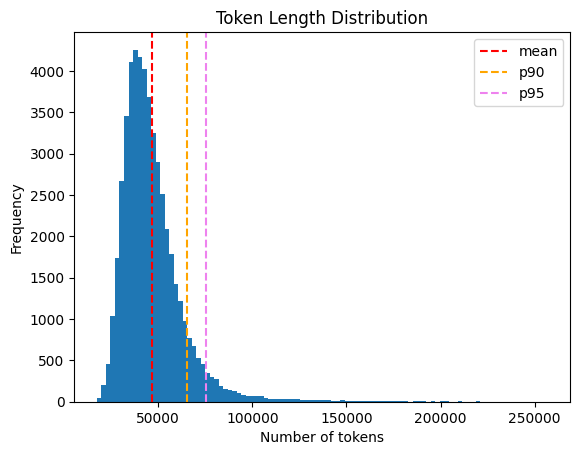

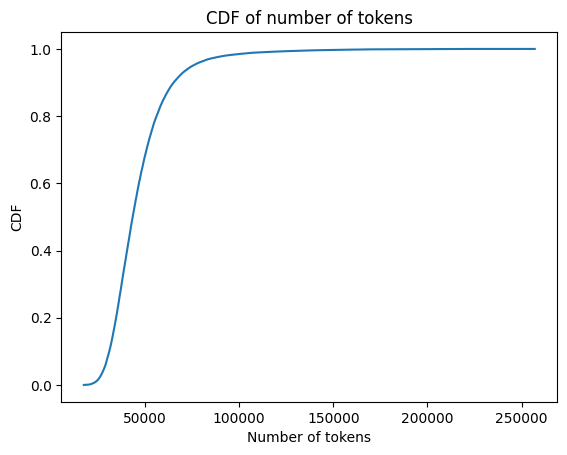

In [42]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(lengths, bins=100)

plt.axvline(np.mean(lengths), linestyle="--", label="mean", c='r')
plt.axvline(np.percentile(lengths, 90), linestyle="--", label="p90", c='orange')
plt.axvline(np.percentile(lengths, 95), linestyle="--", label="p95", c='violet')

plt.legend()
plt.xlabel("Number of tokens")
plt.ylabel("Frequency")
plt.title("Token Length Distribution")
plt.show()

sorted_lengths = sorted(lengths)
cdf = np.arange(len(sorted_lengths)) / len(sorted_lengths)

plt.figure()
plt.plot(sorted_lengths, cdf)
plt.xlabel("Number of tokens")
plt.ylabel("CDF")
plt.title("CDF of number of tokens")
plt.show()

In [11]:
MODEL_PATH = "/var/essdata/DN_1/storage/home/ttn/models/Qwen3-4B"
DATA_PATH = "/var/essdata/DN_1/storage/home/ttn/data/swe_trajectories/nemotron"
OUTPUT_PATH = "/var/essdata/DN_1/storage/home/ttn/models/qwen3-4b-swe-lora"

In [12]:
MAX_SEQ_LENGTH = 50000

In [13]:
from unsloth import FastLanguageModel
import torch

# Загрузка модели
print("Загрузка модели...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_PATH,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=torch.bfloat16, # тип данных для вычислений
    load_in_4bit=True
)

# Настройка LoRA
model = FastLanguageModel.get_peft_model(
    model,
    r=16,  # ранг LoRA
    lora_alpha=32,  # alpha = 2*r для лучшей обучаемости
    lora_dropout=0.0,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",  # attention слои
        "gate_proj", "up_proj", "down_proj",  # MLP слои
    ],
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
)

Загрузка модели...
==((====))==  Unsloth 2026.2.1: Fast Qwen3 patching. Transformers: 4.57.6.
   \\   /|    NVIDIA H100 PCIe. Num GPUs = 1. Max memory: 79.18 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 9.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


[unsloth_zoo.log|WARNING]Unsloth: /var/essdata/DN_1/storage/home/ttn/models/Qwen3-4B can only handle sequence lengths of at most 40960.
But with kaiokendev's RoPE scaling of 1.221, it can be magically be extended to 50000!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Unsloth 2026.2.1 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


In [14]:
from trl import SFTTrainer, SFTConfig

trainer = SFTTrainer(
    model=model, # Модель, которую мы обучаем. Обучаются только LoRA-параметры, а не вся модель
    train_dataset=ds, # наш подготовленный датасет
    tokenizer=tokenizer, # tokenizer; используется для преобразования текста в токены и паддинга последовательностей (если последовательность < max_seq_length)
    args=SFTConfig( # гиперпараметры обучения
        max_seq_length=MAX_SEQ_LENGTH, # максимальная длина входной последовательности токенов, которую модель может обработать за один раз
        per_device_train_batch_size=2, # Сколько примеров обрабатывается за один шаг в расчёте на один (!) GPU
        gradient_accumulation_steps=4, # Позволяет имитировать большой batch size. Идея: 1 шаг → считаем градиенты, но не обновляем веса
                                       # После 4 шага: градиенты суммируются → обновляем веса.
                                       # Формула эффективного batch effective_batch_size = per_device_train_batch_size * число GPU * gradient_accumulation
                                       # У нас: 2 * 1 (т.к. у нас 1 GPU) * 4 = 8. То есть модель фактически обучается на 8 примерах за шаг обновления.
        warmup_steps=10, # Первые шаги обучения делают плавный разогрев (↑) learning rate (предотвращает нестабильное обучение, уменьшает риск разрушить веса модели)
        #num_train_epochs=2, # !ИЗМЕНЕНО!
        max_steps=60,  # TODO: experiment with different values (try 60–200) Максимальное количество шагов обучения. Каждый шаг: forward + backward + update. Удобно для быстрых экспериментов вместо num_train_epochs
        learning_rate=2e-4,  # TODO: experiment with different values (try 1e-4 to 5e-4)
        logging_steps=1, # Как часто выводить метрики. 1 = каждый шаг !ИЗМЕНЕНО!
        output_dir=OUTPUT_PATH, # Папка, куда сохраняются: checkpoints, финальная модель, логи
        optim="adamw_8bit", # adamw_8bit — версия AdamW с 8-битными состояниями. Использует библиотеку bitsandbytes. Плюсы: меньше VRAM и почти та же точность
        weight_decay=0.01, # Регуляризация. Добавляет штраф за большие веса: loss = original_loss + λ * ||weights||. Помогает избежать переобучения.
        lr_scheduler_type="linear", # Как меняется learning rate во времени. linear означает: warmup → затем плавное уменьшение
        seed=42,
        report_to="none", # Отключает логирование в сервисы вроде Weights & Biases и TensorBoard
        #dataset_text_field="text", # по умолчанию "text" — Name of the column that contains text data in the dataset
    ),
)

effective_batch_size = (
    trainer.args.per_device_train_batch_size
    * trainer.args.gradient_accumulation_steps
)
steps_per_epoch = len(ds) // effective_batch_size # сколько шагов в одной эпохе

print(f"Effective batch size: {effective_batch_size}")
print(f"Steps per epoch: {steps_per_epoch}")
print(f"Total training steps: {trainer.args.max_steps}")
print(f"Approximate epochs: {trainer.args.max_steps / steps_per_epoch:.2f}") # max_steps < steps_per_epoch, то модель не проходит весь датасет даже один раз.
print(f"Learning rate: {trainer.args.learning_rate}")

Unsloth: Tokenizing ["text"] (num_proc=64):   0%|          | 0/51029 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.
Effective batch size: 8
Steps per epoch: 6378
Total training steps: 60
Approximate epochs: 0.01
Learning rate: 0.0002


https://unsloth.ai/docs/basics/troubleshooting-and-faqs#all-labels-in-your-dataset-are-100.-training-losses-will-be-all-0

In [18]:
from unsloth.chat_templates import train_on_responses_only

# всё до <|im_start|>assistant включительно → маскируется (loss = -100)
# всё внутри assistant сообщений → обучается
trainer = train_on_responses_only(
    trainer,
    instruction_part="<|im_start|>user", # "<|im_start|>assistant\n" м.б. так получше
    response_part="<|im_start|>assistant", # "<|im_start|>assistant\n" м.б. так получше
)

Map (num_proc=64):   0%|          | 0/51029 [00:00<?, ? examples/s]

Filter (num_proc=64):   0%|          | 0/51029 [00:00<?, ? examples/s]

Если выдало предупреждение наподобие этого: `Unsloth: Removed 1483 out of 51029 samples from train_dataset where all labels were -100 (no response found after truncation). This prevents NaN loss during training.`, то это значит, что некоторые траектории были удалены из датасета из-за параметра max_seq_length, который настолько сильно обрезал их, что в них остались только начальные замаскированные токены (-100)

In [20]:
batch = next(iter(trainer.get_train_dataloader()))
print(batch["labels"][0])
print(len(batch["labels"][0]))

tensor([-100, -100, -100,  ...,  220,   18,   13], device='cuda:0')
50000


Каждое число = id токена<br>
Точнее:
| Значение | Что означает                      |
| -------- | --------------------------------- |
| `>= 0`   | токен, по которому считается loss |
| `-100`   | **игнорируется (masked) при расчёте loss**         |


In [21]:
# выведем для первой траектории токены и их id

input_ids = batch["input_ids"][0]
labels = batch["labels"][0]
tokens = tokenizer.convert_ids_to_tokens(input_ids)

for t, l in zip(tokens, labels):
    print(f"{t:20} | {l}")

<|im_start|>         | -100
system               | -100
Ċ                    | -100
You                  | -100
Ġare                 | -100
ĠOpen                | -100
Hands                | -100
Ġagent               | -100
,                    | -100
Ġa                   | -100
Ġhelpful             | -100
ĠAI                  | -100
Ġassistant           | -100
Ġthat                | -100
Ġcan                 | -100
Ġinteract            | -100
Ġwith                | -100
Ġa                   | -100
Ġcomputer            | -100
Ġto                  | -100
Ġsolve               | -100
Ġtasks               | -100
.ĊĊ                  | -100
<                    | -100
ROLE                 | -100
>Ċ                   | -100
Your                 | -100
Ġprimary             | -100
Ġrole                | -100
Ġis                  | -100
Ġto                  | -100
Ġassist              | -100
Ġusers               | -100
Ġby                  | -100
Ġexecuting           | -100
Ġcommands           

In [ ]:
# Обучение
print("Начало обучения...")
trainer.train()

# Сохранение модели
#print("Сохранение модели...")
#model.save_pretrained_merged(
#    OUTPUT_PATH,
#    tokenizer,
#    save_method="merged_16bit",
#)

#print(f"Обучение завершено! Модель сохранена в {OUTPUT_PATH}")